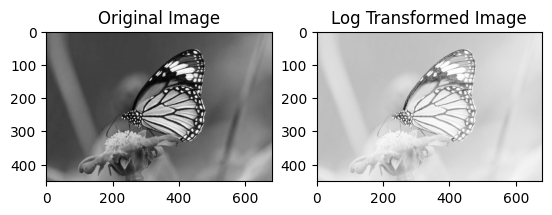

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("image_input.jpg", cv2.IMREAD_GRAYSCALE)


c = 1
log_transformed = c * (np.log1p(image.astype(np.float64)))


log_transformed = cv2.normalize(log_transformed, None, 0, 255, cv2.NORM_MINMAX)
log_transformed = np.uint8(log_transformed)

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Log Transformed Image")
plt.imshow(log_transformed, cmap='gray')

plt.show()


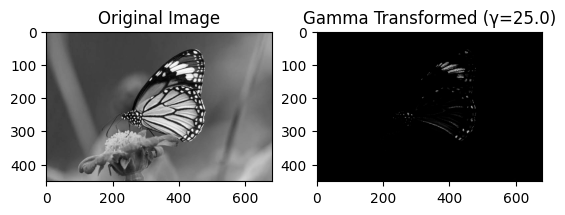

In [2]:
gamma = float(input("Enter the value of gamma: "))


c = 1
gamma_transformed = c * np.power(image / 255.0, gamma)


gamma_transformed = cv2.normalize(gamma_transformed, None, 0, 255, cv2.NORM_MINMAX)
gamma_transformed = np.uint8(gamma_transformed)


plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"Gamma Transformed (γ={gamma})")
plt.imshow(gamma_transformed, cmap='gray')


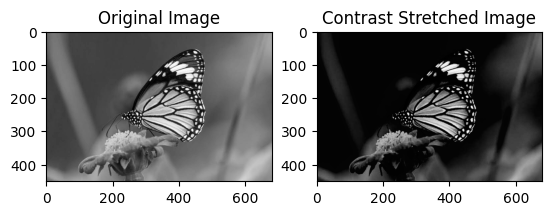

In [3]:
r1 = int(input("Enter lower bound of input intensity range: "))
r2 = int(input("Enter upper bound of input intensity range: "))
s1 = int(input("Enter lower bound of output intensity range: "))
s2 = int(input("Enter upper bound of output intensity range: "))


output = np.zeros_like(image, dtype=np.float64)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        pixel = image[i, j]
        if pixel < r1:
            output[i, j] = (s1 / r1) * pixel
        elif pixel <= r2:
            output[i, j] = ((s2 - s1) / (r2 - r1)) * (pixel - r1) + s1
        else:
            output[i, j] = ((255 - s2) / (255 - r2)) * (pixel - r2) + s2


output = cv2.normalize(output, None, 0, 255, cv2.NORM_MINMAX)
output = np.uint8(output)


plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Contrast Stretched Image")
plt.imshow(output, cmap='gray')

plt.show()